In [1]:
import numpy as np
from scipy import signal as sg
import matplotlib
import matplotlib.pyplot as plt

![](spec.png)

0.8912509381337456 0.01
Saved spec_plot.png


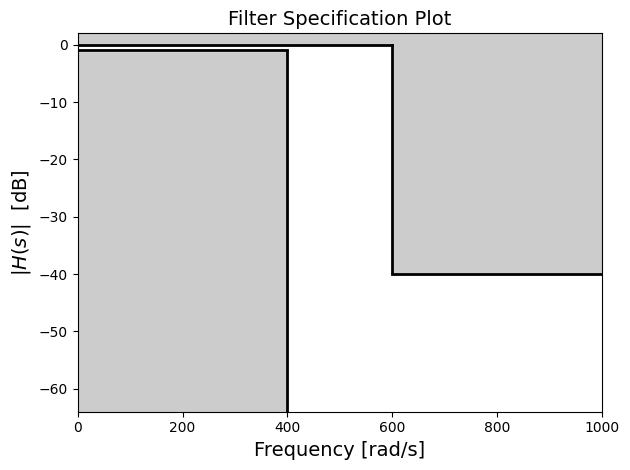

In [16]:
# Spec visualization
passband_ripple = pow(10, (-1/20))
stopband_ripple = pow(10, (-2))
wp = 400
ws = 600
gpass = 1
gstop = 40

print(passband_ripple, stopband_ripple)


figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Filter Specification Plot', fontsize=14)


# Passband restriction
ax.axhline(y=0, xmin=0, xmax=0.6, color='black', lw=2)
ax.axhline(y=-passband_ripple, xmin=0, xmax=0.4, color='black', lw=2)

# Transition band restriction
ax.axvline(x=400, ymax= 0.985 - (3-passband_ripple) / 66, color='black', lw=2)
ax.axvline(x=600, ymin= 0.975 - gstop / 66, ymax= 1 - (3-passband_ripple) / 66, color='black', lw=2)

# Stopband restriction
ax.axhline(y=-gstop, xmin=0.6, xmax=1, color='black', lw=2)

ax.set_xlabel(r'Frequency [rad/s]', fontsize=14)
ax.set_xlim(0, 1000)

ax.set_ylabel(r'$|H(s)|$  [dB]', fontsize=14)
ax.set_ylim(ymin=-64, ymax=2)

# Shading
w = np.linspace(0,1000,1000)
ax.fill_between(w, -64, where = w < wp, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, 2, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, -gstop, where = w > ws, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, -gpass, where = w < wp, color='white', alpha=1, zorder=1)

plt.tight_layout()
plt.savefig('spec_plot.png', dpi=150, bbox_inches='tight')
print("Saved spec_plot.png")

In [3]:
# Find required order
ord_bw, wn_bw = sg.buttord(wp=wp, ws=ws, gpass=gpass, gstop=gstop, analog=True)
ord_chI, wn_chI = sg.cheb1ord(wp=wp, ws=ws, gpass=gpass, gstop=gstop, analog=True)
ord_chII, wn_chII = sg.cheb2ord(wp=wp, ws=ws, gpass=gpass, gstop=gstop, analog=True)
ord_ell, wn_ell = sg.ellipord(wp=wp, ws=ws, gpass=gpass, gstop=gstop, analog=True)

print(ord_bw, ord_chI, ord_chII, ord_ell)

14 7 7 5


In [4]:
# Design filters
bw_z, bw_p, bw_k = sg.butter(N=ord_bw, Wn=wn_bw, analog=True, output='zpk')
chI_z, chI_p, chI_k = sg.cheby1(N=ord_chI, Wn=wn_chI, analog=True, output='zpk', rp=1)
chII_z, chII_p, chII_k = sg.cheby2(N=ord_chII, Wn=wn_chII, analog=True, output='zpk', rs=40)
ell_z, ell_p, ell_k = sg.ellip(N=ord_ell, Wn=wn_ell, analog=True, output='zpk', rp=1, rs=40)
bess_z, bess_p, bess_k = sg.bessel(N=ord_bw, Wn=wn_bw, analog=True, output='zpk')

In [5]:
# Magnitude Responses
bw_w, bw_resp = sg.freqs_zpk(z=bw_z, p=bw_p, k=bw_k, worN=np.linspace(0,1000,1000))
chI_w, chI_resp = sg.freqs_zpk(z=chI_z, p=chI_p, k=chI_k, worN=np.linspace(0,1000,1000))
chII_w, chII_resp = sg.freqs_zpk(z=chII_z, p=chII_p, k=chII_k, worN=np.linspace(0,1000,1000))
ell_w, ell_resp = sg.freqs_zpk(z=ell_z, p=ell_p, k=ell_k, worN=np.linspace(0,1000,1000))
bess_w, bess_resp = sg.freqs_zpk(z=bess_z, p=bess_p, k=bess_k, worN=np.linspace(0,1000,1000))

bw_resp = 20 * np.log10(abs(bw_resp))
chI_resp = 20 * np.log10(abs(chI_resp))
chII_resp = 20 * np.log10(abs(chII_resp))
ell_resp = 20 * np.log10(abs(ell_resp))
bess_resp = 20 * np.log10(abs(bess_resp))

Saved mag_response.png


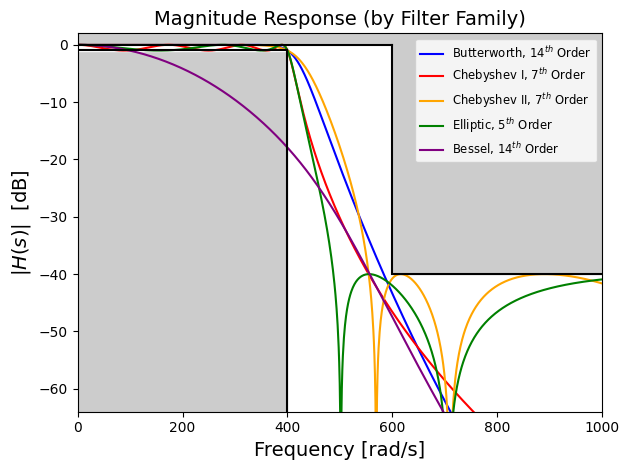

In [15]:
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Magnitude Response (by Filter Family)', fontsize=14)

# Passband restriction
ax.axhline(y=0, xmin=0, xmax=0.6, color='black', lw=1.5, zorder=3)
ax.axhline(y=-passband_ripple, xmin=0, xmax=0.4, color='black', lw=1.5, zorder=3)

# Transition band restriction
ax.axvline(x=400, ymax= 0.985 - (3-passband_ripple) / 66, color='black', lw=1.5, zorder=3)
ax.axvline(x=600, ymin= 0.975 - gstop / 66, ymax= 1 - (3-passband_ripple) / 66, color='black', lw=1.5, zorder=3)

# Stopband restriction
ax.axhline(y=-gstop, xmin=0.6, xmax=1, color='black', lw=1.5, zorder=3)

ax.set_xlabel(r'Frequency [rad/s]', fontsize=14)
ax.set_xlim(0, 1000)

ax.set_ylabel(r'$|H(s)|$  [dB]', fontsize=14)
ax.set_ylim(ymin=-64, ymax=2)


# Butterworth
ax.plot(bw_w, bw_resp, color='blue', label="Butterworth, $14^{th}$ Order", zorder=2)
ax.plot(chI_w, chI_resp, color='red', label="Chebyshev I, $7^{th}$ Order", zorder=2)
ax.plot(chII_w, chII_resp, color='orange', label="Chebyshev II, $7^{th}$ Order", zorder=2)
ax.plot(ell_w, ell_resp, color='green', label="Elliptic, $5^{th}$ Order", zorder=2)
ax.plot(bess_w, bess_resp, color='purple', label="Bessel, $14^{th}$ Order", zorder=2)

# Shading
w = np.linspace(0,1000,1000)
ax.fill_between(w, -64, where = w < wp, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, 2, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, -gstop, where = w > ws, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, -gpass, where = w < wp, color='white', alpha=1, zorder=1)

plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.savefig('mag_response.png', dpi=150, bbox_inches='tight')
print("Saved mag_response.png")